In [ ]:
# 필요한 패키지 설치
# ! pip install yellowbrick
# yellowbrick은 머신러닝 모델의 시각화 도구로, 특히 클러스터 개수 결정이나 군집 품질 평가에 유용함
# KMeans의 최적 군집 수 찾기(KElbowVisualizer), 실루엣 계수 시각화(SilhouetteVisualizer) 등을 지원함

from sklearn.preprocessing import MinMaxScaler
# 피처 값들을 0~1 범위로 정규화하기 위한 전처리 도구 불러오기
# 거리 기반 알고리즘(KMeans, DBSCAN 등)에서 각 피처의 영향력을 균등하게 하기 위한 필수 작업임

from sklearn.cluster import KMeans
# KMeans 클러스터링 알고리즘 클래스 불러오기
# 지정된 k개의 중심점을 기준으로 데이터를 군집화하는 대표적인 비지도 학습 기법임

from yellowbrick.cluster import KElbowVisualizer
# KMeans의 최적 클러스터 수(k)를 탐색하기 위한 엘보우 시각화 도구 불러오기
# 각 k에 대한 SSE(제곱합 오차) 또는 실루엣 계수를 기준으로 군집 수 결정에 도움을 줌

from sklearn.metrics import silhouette_score
# 군집 품질을 평가하는 지표 중 하나인 실루엣 계수를 계산하기 위한 함수 불러오기
# -1 ~ 1 사이 값이며, 1에 가까울수록 군집이 잘 분리되었음을 의미함

from yellowbrick.cluster import SilhouetteVisualizer
# 클러스터별 실루엣 계수를 시각화하는 도구 불러오기
# 각 데이터가 자신의 군집 내에 얼마나 잘 속해 있는지를 시각적으로 표현함

from sklearn.cluster import DBSCAN
# 밀도 기반 클러스터링 알고리즘 DBSCAN 클래스 불러오기
# 이상치(outlier)를 자동 감지하고, 밀도가 높은 영역을 군집으로 정의하는 알고리즘임

import pandas as pd
# 데이터프레임 구조의 데이터를 다루기 위한 pandas 라이브러리 불러오기
# 데이터 로딩, 가공, 피처 분리, 시각화 대상 추출 등 데이터 처리의 기본 도구임

import seaborn as sns
# 통계 기반 시각화를 지원하는 seaborn 라이브러리 불러오기
# 군집 분포 확인, 히트맵, 상관 행렬 등 고급 시각화에 주로 사용됨

import matplotlib.pyplot as plt
# matplotlib의 그래프 도구인 pyplot 불러오기
# 꺾은선, 산점도, 막대그래프 등 모든 시각화 출력의 기본 툴로 활용됨


In [ ]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
df = pd.read_csv("datasets/Mall_Customers.csv")

# 데이터 샘플 확인
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


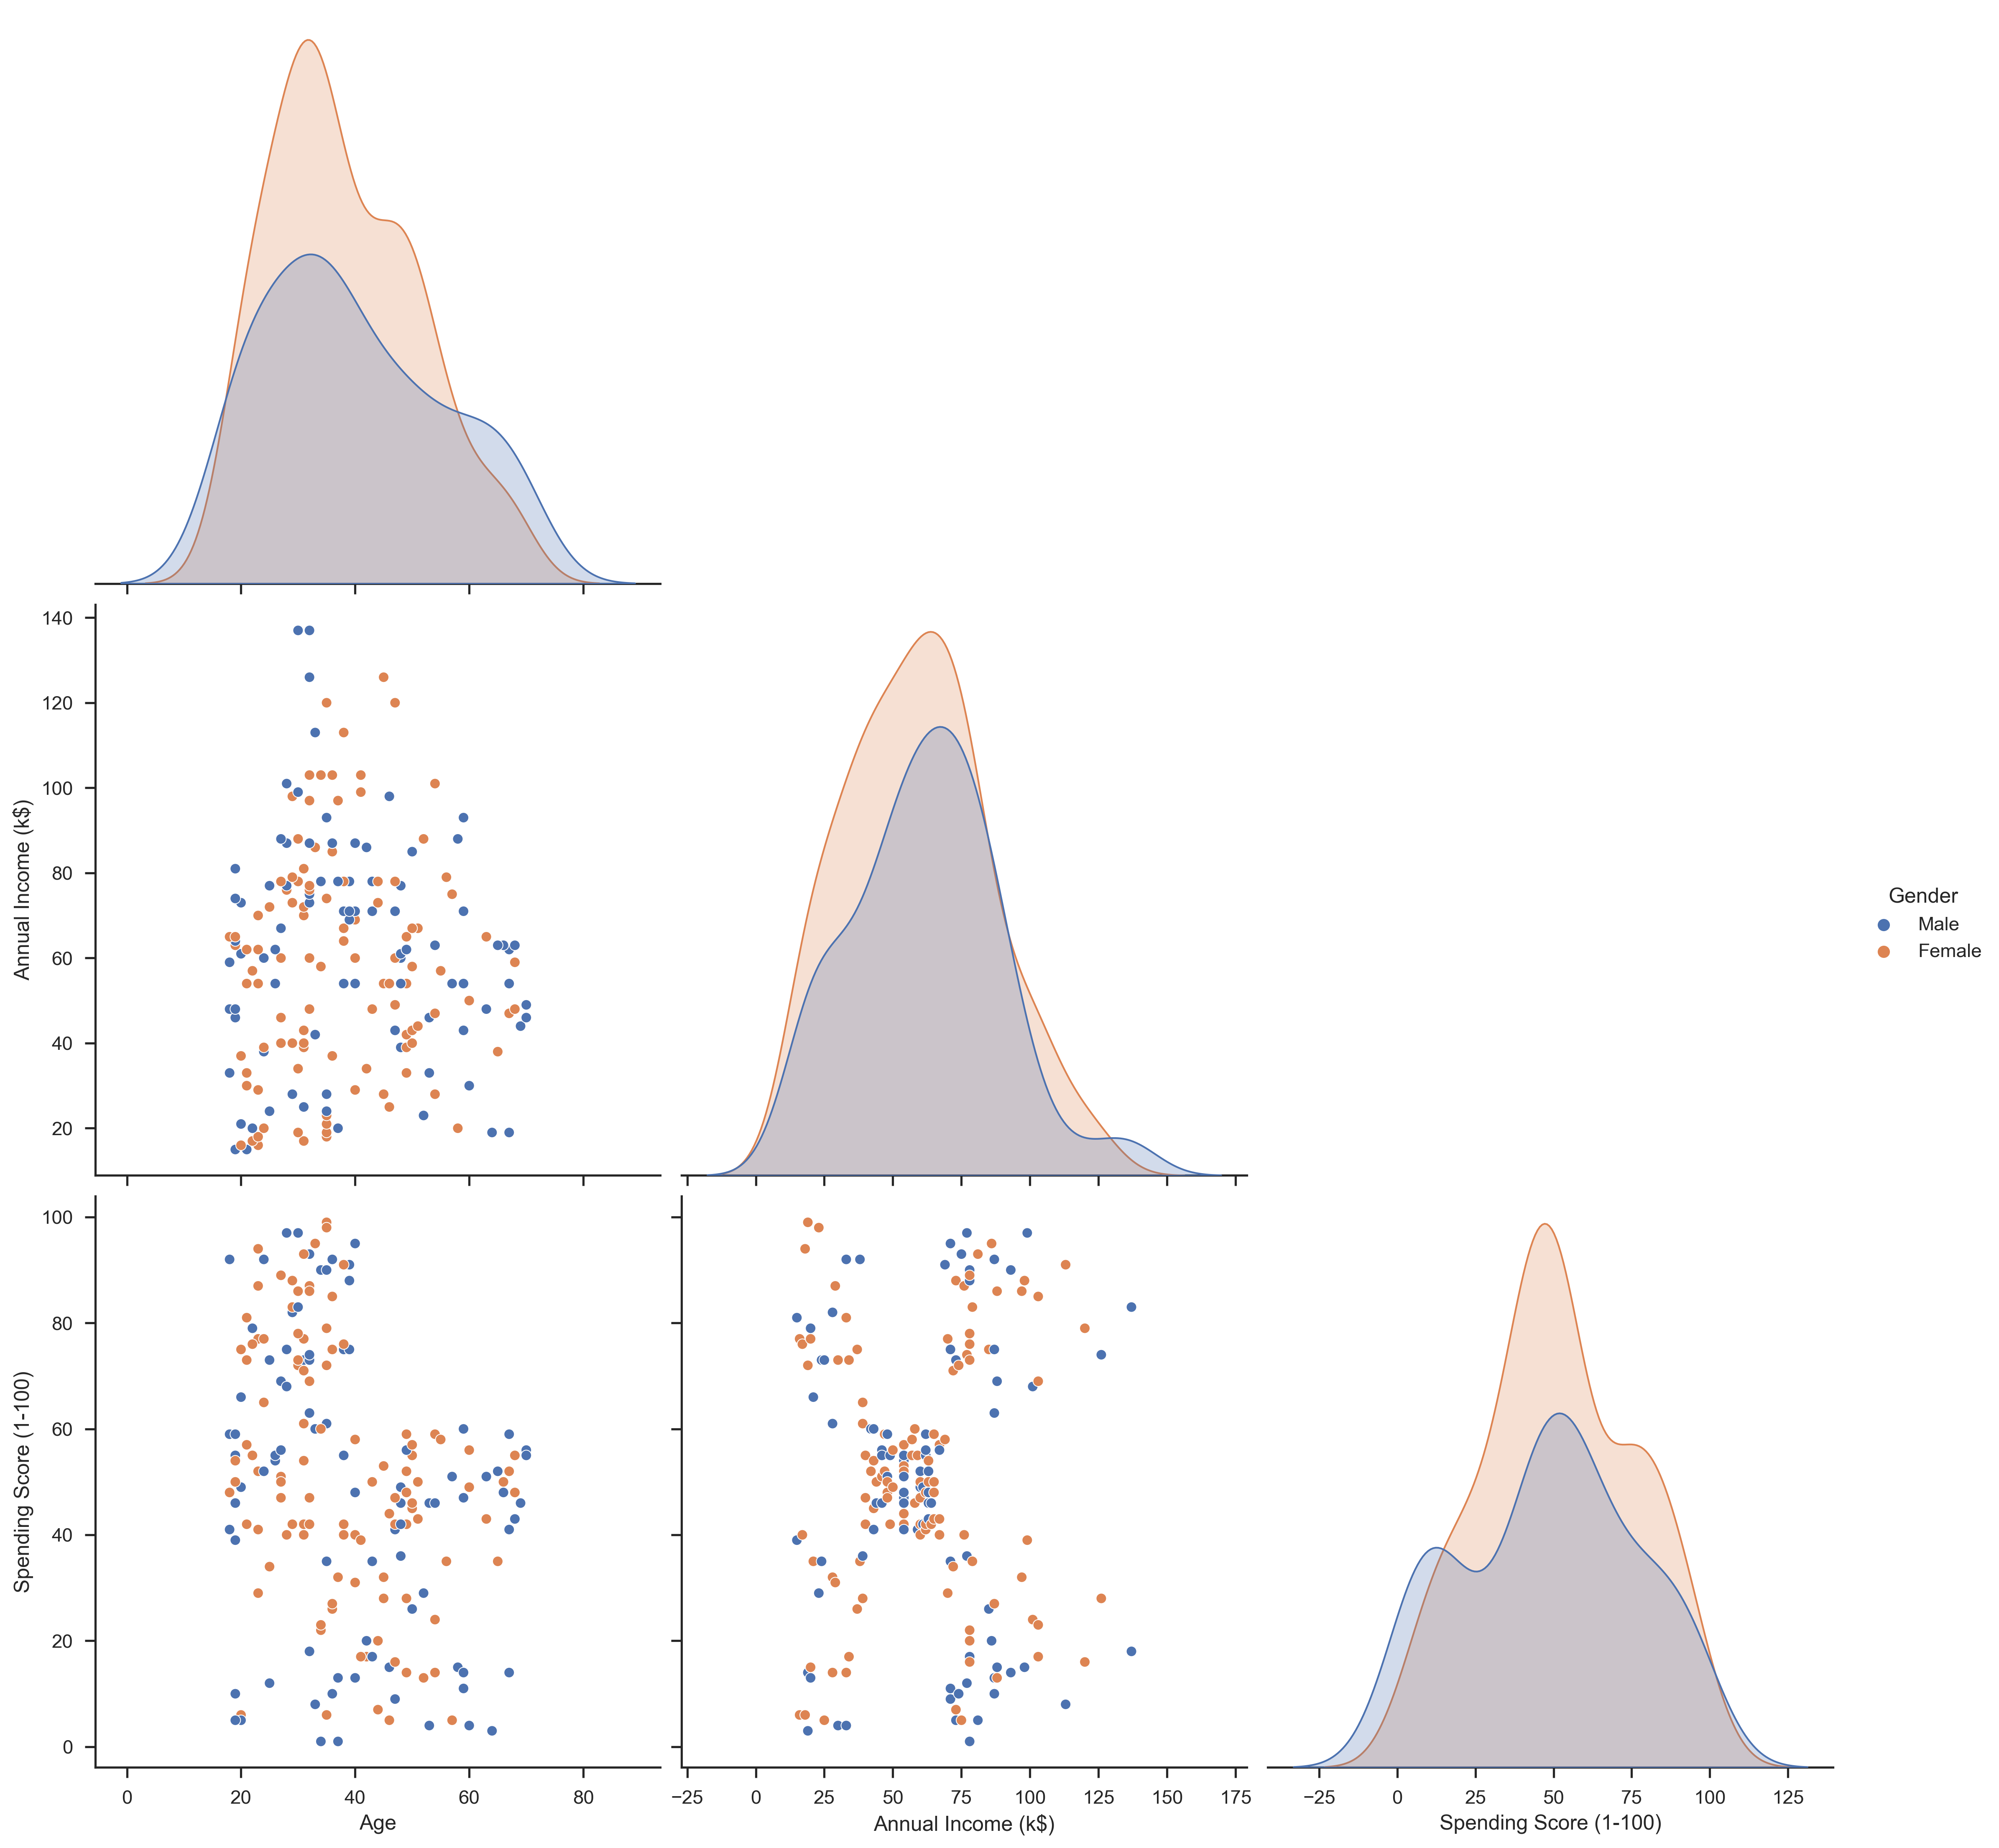

In [ ]:
# 산점도 행렬 시각화

# ID 컬럼 제거
df1 = df.drop('CustomerID', axis=1)
# 분석과 시각화에 불필요한 식별자 역할의 'CustomerID' 열을 제거함
# 클러스터링이나 시각화에 영향을 주지 않도록 고유 키 변수는 사전에 제외하는 것이 일반적인 전처리 절차임

sns.set(font_scale=1)
# 시각화에서 사용되는 폰트 크기를 기본값(1)로 설정함
# 가독성과 전체 비율 조절을 위한 시각화 스타일 설정임

sns.set_style('ticks')
# 그래프 스타일을 'ticks'로 지정하여 테두리 축을 포함한 깔끔한 시각화 구성 설정함
# 눈금이 있는 미니멀한 스타일로 데이터 중심의 시각화를 제공함

sns.pairplot(df1, 
             diag_kind='kde', # 상관계수가 1이면 분포로 표시
             hue='Gender',
             corner=True,
             height=5
            )
# 여러 수치형 변수 간의 관계를 시각화하는 산점도 행렬(pairplot)을 생성함
# diag_kind='kde'는 대각선에 각 변수의 분포를 커널 밀도 함수(kde)로 시각화함
# hue='Gender'는 성별에 따라 다른 색상으로 데이터를 구분하여 시각화함
# corner=True는 산점도 행렬의 하삼각형만 출력하여 중복 정보를 줄임
# height=5는 각 subplot의 크기를 5인치로 지정함

plot_kws={"s": 100}
# 각 산점도 점의 크기를 조절하기 위한 설정 변수 정의 (현재 코드에서는 실제 적용되지 않음)
# 일반적으로 sns.pairplot(..., plot_kws=plot_kws) 형태로 전달되어야 적용됨

plt.show()
# 생성된 시각화 결과를 화면에 출력함
# 변수 간 관계(예: Age vs Income, Income vs Spending 등)를 시각적으로 파악하고,  
# 성별에 따라 어떤 군집 경향이 나타나는지를 탐색하기 위한 목적임


### 대각선 그래프가 보여주는 정보

| 변수 이름 | 대각선 그래프 의미 |
| --- | --- |
| `Age` | 전체 고객의 연령 분포. 20~40대에 몰려 있는지 확인 가능 |
| `Annual Income` | 연소득이 어느 구간에 몰려 있는지 확인 가능 |
| `Spending Score` | 소비 점수가 어떤 범위에 집중되어 있는지 확인 가능 |


| 위치 | 의미 |
| --- | --- |
| **대각선** | **변수 자기 자신의 분포** |
| **비대각선** | **두 변수 간의 관계(산점도)** |

In [ ]:
# 데이터 스케일 정규화

# Gender 변수 가변수 처리
df2 = pd.get_dummies(df1, columns=['Gender'], drop_first=True)
# 성별(Gender) 변수는 범주형 변수이므로 머신러닝에 사용할 수 있도록 수치형 변수로 변환함
# pd.get_dummies() 함수는 'Male', 'Female'을 0 또는 1의 이진 변수로 변환함
# drop_first=True는 첫 번째 범주('Female')를 제거하고, 나머지('Male')만 표시하여 다중공선성 문제를 방지함
# 결과적으로 'Gender_Male'이라는 열이 생성되며, 남성이면 1, 여성이면 0으로 표현됨

# 데이터 정규화 적용
MinMaxScaler = MinMaxScaler()
# MinMaxScaler 객체를 생성하여 모든 수치형 피처를 0~1 범위로 정규화하기 위한 준비 작업 수행함
# 이는 피처 간의 크기 차이로 인해 거리 기반 알고리즘(KMeans 등)이 왜곡되는 것을 방지하기 위한 사전 처리임

df_minmax = MinMaxScaler.fit_transform(df2)
# 데이터프레임 df2에 대해 정규화를 수행함
# fit()은 각 피처의 최소값과 최대값을 학습하고, transform()은 이를 기반으로 0~1 범위로 값을 재조정함
# 반환 값은 ***numpy 배열 형태***이며, 원래의 피처 스케일이 제거된 상태임

# 컬럼명 결합
df_minmax = pd.DataFrame(data=df_minmax, columns=df2.columns)
# 정규화된 numpy 배열을 다시 pandas DataFrame 형태로 복원함
# 원래 df2의 컬럼명을 그대로 사용하여 가독성과 해석 가능성을 유지함
# 이후 클러스터링 알고리즘 입력으로 사용하기 위해 최종 전처리된 상태로 준비됨

df_minmax.head()
# 정규화된 결과의 상위 5개 행을 출력함
# 데이터가 0~1 사이의 범위로 잘 정규화되었는지, 이상값이나 변환 오류가 없는지를 시각적으로 점검하는 목적임


,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,0.019231,0.000000,0.387755,1.0
1,0.057692,0.000000,0.816327,1.0
2,0.038462,0.008197,0.051020,0.0
3,0.096154,0.008197,0.775510,0.0
4,0.250000,0.016393,0.397959,0.0


In [ ]:
# ✅ K-Means 클러스터링 알고리즘 이해를 위한 핵심 개념 정리

# ▶ 1. K-Means란?
# K-Means는 비지도 학습(unupervised learning)에 속하는 대표적인 **군집화(clustering)** 알고리즘임
# 주어진 데이터를 유사한 성질끼리 **K개의 그룹(cluster)**으로 나누는 것이 목적임
# 각 군집은 하나의 중심점(centroid)을 기준으로 하며, **거리 기반**으로 데이터를 배정함

# ▶ 2. 작동 방식 (반복적 최적화 알고리즘)
# ① 임의로 K개의 중심점(centroids)을 초기화함  
# ② 각 데이터를 **가장 가까운 중심점에 할당**하여 K개의 군집을 구성함  
# ③ 각 군집 내 데이터를 평균내어 새로운 중심점을 계산함  
# ④ 중심점 변화가 거의 없을 때까지 또는 최대 반복 횟수까지 ②~③을 반복함  

# ▶ 3. 거리 계산 방식
# 기본적으로 **유클리디안 거리(Euclidean distance)**를 사용함  
# 두 점 x = (x1, x2, ..., xn), y = (y1, y2, ..., yn) 간 거리는 아래와 같음:  
# 거리(x, y) = sqrt( (x1 - y1)^2 + (x2 - y2)^2 + ... + (xn - yn)^2 )

# ▶ 4. 목적 함수: SSE (Sum of Squared Errors)
# K-Means는 다음의 손실 함수를 최소화하는 것이 목표임:
# SSE = Σᵢ Σⱼ || xᵢⱼ - μⱼ ||²
# - xᵢⱼ: j번째 클러스터에 속한 i번째 데이터 포인트  
# - μⱼ: j번째 클러스터의 중심점  
# → 각 클러스터 내부의 데이터들이 중심점과 얼마나 가까운지를 나타냄  
# → SSE가 작을수록 군집 내부가 더 응집되어 있음

# ▶ 5. 주요 하이퍼파라미터

# - n_clusters: 군집 수(K)  
# - init: 중심점 초기화 방식 (일반적으로 'k-means++' 사용)  
# - n_init: 서로 다른 초기값으로 몇 번 반복 실행할지 (최적 SSE 선택 목적)  
# - max_iter: 각 실행 당 반복 횟수 제한  
# - random_state: 결과 재현성 확보를 위한 시드값

# ▶ 6. K-Means의 장점과 한계

# ✅ 장점:
# - 대규모 데이터에 대해서도 빠르게 작동함
# - 구현이 간단하고 해석이 직관적임
# - 수치형 데이터 중심의 클러스터링에 효과적임

# ❌ 단점:
# - K(군집 수)를 사전에 지정해야 함 → 엘보우 기법 등의 평가 필요
# - 군집 모양이 구형(spherical)이 아니면 성능 저하 가능성 있음
# - 이상치(outlier)에 민감함
# - 군집 크기가 서로 다를 경우 왜곡 가능성 존재

# ▶ 7. 실무 적용 시 고려사항
# - 스케일이 다른 피처는 반드시 **정규화 또는 표준화** 수행 필요
# - 적절한 K값을 찾기 위해 **Elbow Method**, **Silhouette Score** 사용 권장
# - 초기 중심점 설정에 따라 결과가 달라질 수 있으므로 n_init 값을 크게 설정하는 것이 일반적임


# ---------------------------------------------------------------------

# k-means 클러스터링 모델 생성

kmeans_model_1 = KMeans(
    init="k-means++",
    n_clusters=3,
    n_init=10,
    max_iter=300,
    random_state=37
)
# KMeans 알고리즘을 사용하여 클러스터링 모델 객체를 생성함
# init="k-means++"는 초기 중심점을 무작위가 아닌, 데이터 간 거리를 고려하여 뽑는 방식임
# → 수렴 속도 향상 및 지역 최적 해 방지 효과가 있음
# n_clusters=3은 군집의 개수를 3개로 설정함
# n_init=10은 서로 다른 초기 중심점으로 모델을 10번 실행하고, 그중 SSE가 가장 낮은 결과를 선택함
# max_iter=300은 각 실행당 최대 반복 횟수를 300으로 설정하여 수렴을 유도함
# random_state=37은 결과 재현성을 위해 난수 시드를 고정함

kmeans_model_1.fit(df_minmax)
# 정규화된 데이터(df_minmax)를 이용해 KMeans 클러스터링을 수행함
# 각 데이터는 가장 가까운 중심점(centroid)에 할당되며, 반복적으로 중심점을 갱신함
# 이 과정을 통해 전체 데이터가 3개의 군집으로 분류됨

# 최저 SSE 값
print(kmeans_model_1.inertia_)
# inertia_는 KMeans 알고리즘의 손실 함수 값(SSE, Sum of Squared Errors)을 의미함
# 각 데이터와 소속된 중심점 간 거리 제곱합의 총합으로, 값이 작을수록 군집이 더 잘 응집되어 있다는 의미임

# 각 군집의 중심점 좌표 확인
print(kmeans_model_1.cluster_centers_)
# 학습이 완료된 후 각 클러스터의 중심 좌표를 출력함
# 각 중심점은 정규화된 피처 공간에서의 평균값으로, 클러스터 대표값 역할을 수행함

# 반복 횟수
print(kmeans_model_1.n_iter_)
# 모델이 수렴할 때까지 반복한 횟수를 출력함
# 수렴이 빠를수록 적절한 초기화와 안정적인 군집 구조를 의미함


29.552857611943853
[[3.86504121e-01 3.62704918e-01 5.15579446e-01 4.44089210e-16]
 [6.04567308e-01 3.88661202e-01 2.87840136e-01 1.00000000e+00]
 [1.97115385e-01 3.85245902e-01 7.21173469e-01 1.00000000e+00]]
2


C:\Users\angry\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1332: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
# 엘보우 차트 시각화

Elbow_Chart = KElbowVisualizer(kmeans_model_1, k=(1, 11))
# KElbowVisualizer 객체를 생성함
# kmeans_model_1은 KMeans 모델 클래스이며, 여기서 모델 구조만 전달됨 (fit은 내부에서 다시 수행됨)
# k=(1, 11)은 클러스터 수 K를 1부터 10까지 변화시키면서 각각의 SSE 값을 측정하겠다는 의미임
# 각 k에 대해 inertia_(=SSE)를 계산하고 이를 시각화함으로써 최적 k를 탐색함

Elbow_Chart.fit(df_minmax)
# 정규화된 데이터(df_minmax)를 사용하여 각 클러스터 수(k)에 대한 KMeans 모델을 반복 학습시킴
# 각 학습 결과에 대해 SSE(inertia_) 값을 수집함
# 내부적으로 n_clusters=k[i]를 바꿔가며 여러 번 모델을 학습함

Elbow_Chart.draw()
# 계산된 k별 SSE 값을 시각화하여 꺾은선 그래프(엘보우 차트)를 그림
# 그래프에서 SSE 감소가 급격히 완화되는 지점이 엘보우(elbow)이며, 해당 지점의 k가 **최적 클러스터 수**로 간주됨


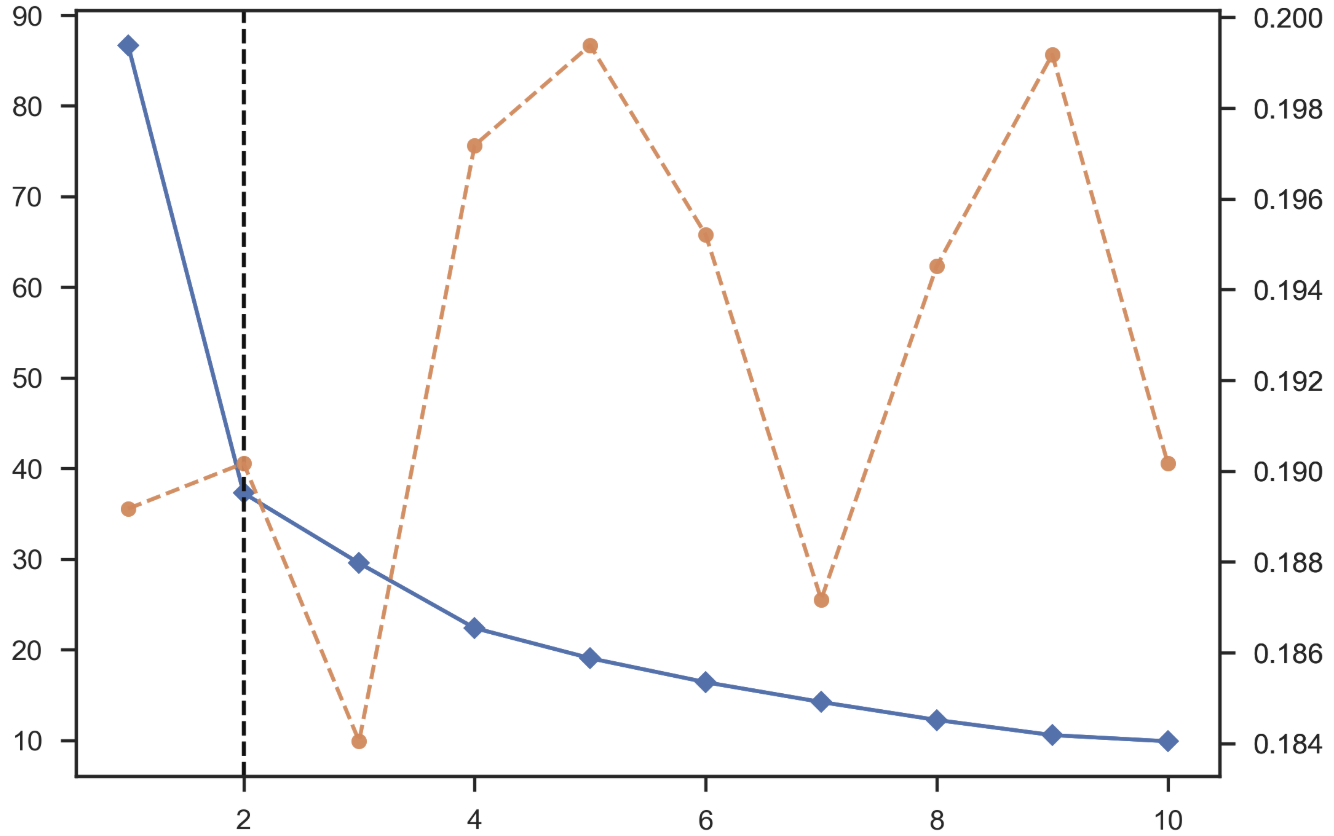

### 개념: Silhouette Coefficient

| 지표 이름 | 의미 |
| --- | --- |
| **실루엣 계수** | 군집 내 응집도와 군집 간 분리도를 동시에 고려한 지표 |
| **값 범위** | `-1 ≤ score ≤ 1` → 클수록 군집화가 잘 된 구조 |
| **사용 목적** | 최적 클러스터 수(K)를 평가 기준 없이 자동으로 판단 가능 |




---


### 해석

- 실루엣 계수가 **가장 높은 k** → 데이터가 **명확하게 분리된 군집 구조**를 가질 확률이 높음
- 실루엣 계수가 **낮거나 음수** → 일부 샘플이 잘못된 군집에 포함되었을 가능성이 높음

In [ ]:
# 실루엣 계수 시각화 1

# k-means 모델 설정
kmeans_model_2 = {
    "init": "k-means++",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 37,
}
# 공통으로 사용할 KMeans 설정값을 딕셔너리 형태로 정의함
# init='k-means++'는 중심 초기화를 최적화하여 빠른 수렴 유도
# n_init=10은 초기화 10회 반복 후 최적 모델 선택
# max_iter=300은 각 반복당 최대 반복 수 제한
# random_state=37은 결과 재현을 위한 시드 고정

# 각 K의 실루엣 계수 저장
silhouette_coef = []
# 클러스터 수(K)별 실루엣 계수를 저장할 리스트 초기화
# 성능 비교 및 시각화를 위해 누적 기록함

# 실루엣 계수 그래프 생성
for k in range(2, 11):
    # k 값을 2부터 10까지 반복하며 클러스터링 성능 측정

    kmeans_silhouette = KMeans(n_clusters=k, **kmeans_model_2)
    # 현재 k값으로 설정한 KMeans 객체를 생성함
    # 공통 설정값은 **kmeans_model_2 딕셔너리에서 언패킹으로 전달함

    kmeans_silhouette.fit(df_minmax)
    # 정규화된 데이터를 기반으로 클러스터링 수행
    # 각 샘플은 가장 가까운 중심점에 할당되고, 중심점은 반복적으로 갱신됨

    score = silhouette_score(df_minmax, kmeans_silhouette.labels_)
    # 군집 결과에 대한 실루엣 계수를 계산함
    # 실루엣 계수는 [-1, 1] 범위의 값이며, 값이 클수록 군집 간 분리가 잘 된 것임
    # 각 샘플이 자신의 클러스터 안에서 얼마나 잘 위치했는지를 측정하는 지표임

    silhouette_coef.append(score)
    # 계산된 실루엣 계수를 리스트에 저장함

plt.style.use('seaborn-whitegrid')
# 그래프 스타일을 seaborn의 whitegrid 테마로 설정하여 깔끔한 배경과 격자 표시 적용함

plt.plot(range(2, 11), silhouette_coef)
# x축은 클러스터 수, y축은 실루엣 계수 값으로 꺾은선 그래프를 그림
# 클러스터 수에 따른 군집 품질 변화를 시각적으로 확인함

plt.xticks(range(2, 11))
# x축 눈금을 2부터 10까지 지정함 (테스트한 K 값 범위와 일치시킴)

plt.xlabel('Number of Clusters')
# x축 이름을 'Number of Clusters'로 설정함

plt.ylabel('Silhouette Coefficient')
# y축 이름을 'Silhouette Coefficient'로 설정함

plt.show()
# 설정한 그래프를 화면에 출력함
# 실루엣 계수가 가장 높은 k가 **군집 품질이 가장 좋은 클러스터 수**로 해석됨


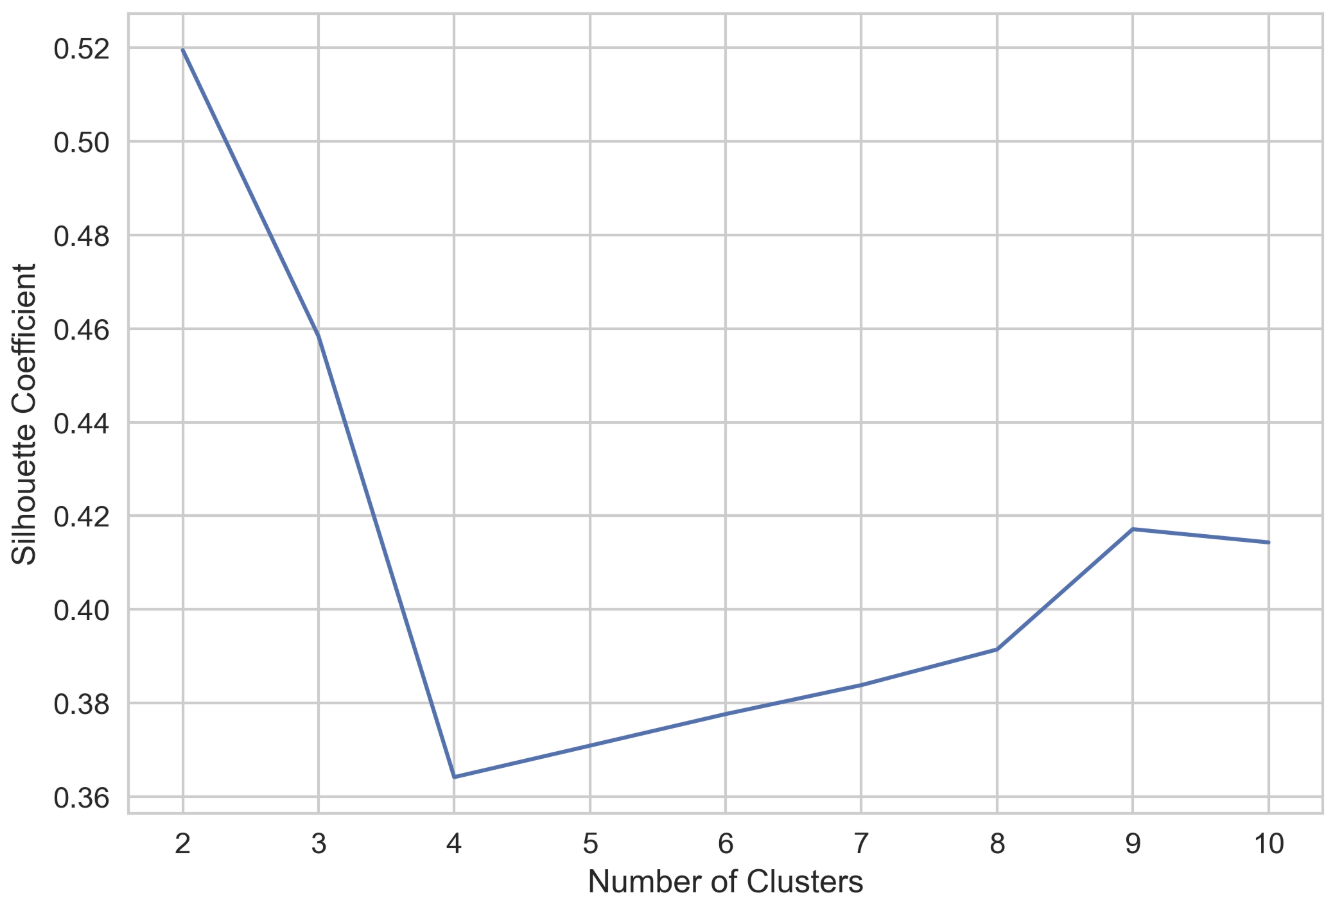

In [ ]:
# 실루엣 계수 시각화 2

fig, ax = plt.subplots(3, 2, figsize=(15, 15))
# 3행 2열의 서브플롯을 생성함 → 총 6개의 시각화 영역을 준비함
# figsize=(15, 15)는 전체 그림의 크기를 지정함
# 실루엣 시각화를 k=2부터 7까지 각각 하나씩 분리하여 표시하기 위한 설정임

for i in [2, 3, 4, 5, 6, 7]:
# 클러스터 수(K)를 2~7까지 변화시키면서 실루엣 시각화를 반복 생성함
# 각 k에 대해 하나의 KMeans 모델을 학습하고, 해당 결과를 개별 subplot에 시각화함

    # k-means 클러스터링 모델 생성
    kmeans_model_3 = KMeans(
        n_clusters=i, 
        init="k-means++", 
        n_init=10, 
        max_iter=300, 
        random_state=37
    )
    # 현재 k값에 대한 KMeans 클러스터링 모델을 생성함
    # 초기화 방식, 반복 횟수, 시드 고정 등은 이전 설정과 동일함

    q, mod = divmod(i, 2)
    # i를 2로 나눈 몫(q)과 나머지(mod)를 구함
    # ax[q-1][mod]에서 subplot의 행과 열 위치를 지정하는 데 사용함
    # 예: i=3 → q=1, mod=1 → ax[0][1] 사용

    # 실루엣 계수 시각화    
    visualizer = SilhouetteVisualizer(
        kmeans_model_3, 
        colors="yellowbrick", 
        ax=ax[q-1][mod]
    )
    # Yellowbrick의 SilhouetteVisualizer 객체 생성
    # 학습된 KMeans 모델을 기반으로 각 샘플의 실루엣 계수를 시각적으로 표현함
    # ax 인자를 통해 결과를 지정된 subplot에 그리도록 설정함
    # colors="yellowbrick"은 기본 Yellowbrick 스타일 색상 적용

    visualizer.fit(df_minmax)
    # 정규화된 데이터에 대해 모델을 학습하고, 실루엣 계수를 계산 및 시각화함
    # 시각화 결과는 각 샘플이 자신의 군집 내에 얼마나 잘 속하는지를 막대 그래프로 보여줌


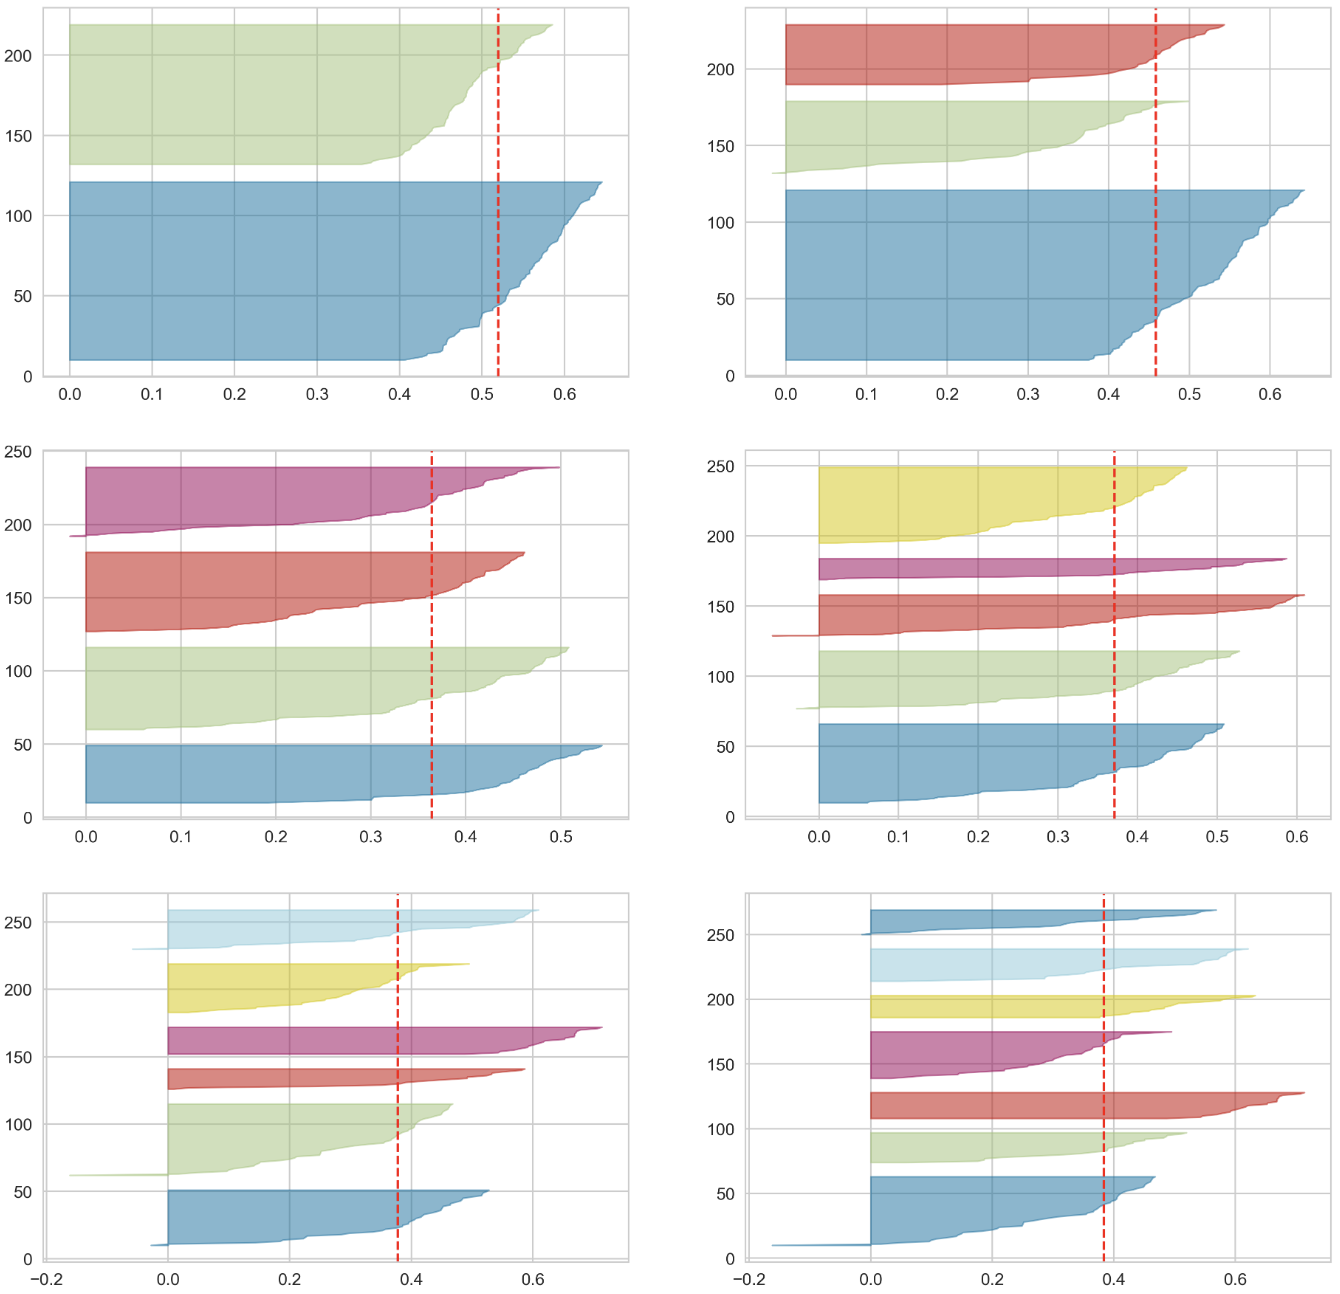

In [ ]:
# k-means 클러스터 시각화

# k-means 모델 설정
kmeans_model_4 = KMeans(
    init="k-means++",
    n_clusters=4,
    n_init=10,
    max_iter=300,
    random_state=37)
# 클러스터 수를 4개로 설정한 KMeans 모델 객체를 생성함
# 중심점 초기화는 'k-means++' 방식으로 설정하여 빠른 수렴을 유도함
# n_init=10은 10번의 다른 초기화로 실행하여 가장 낮은 SSE 결과를 선택함
# max_iter=300은 한 실행 내 최대 반복 횟수를 제한함
# random_state는 결과 재현성을 위한 난수 시드 고정 설정임

# 군집 번호 결합 
df2['cluster1'] = kmeans_model_4.fit_predict(df_minmax)
# 정규화된 데이터(df_minmax)를 기준으로 KMeans 모델을 학습하고, 각 샘플에 대해 군집 번호(라벨)를 예측함
# fit_predict()는 학습과 예측을 한 번에 수행하며, 예측된 군집 번호를 df2에 'cluster1' 열로 추가함
# 군집 결과를 시각화 및 분석에 사용할 수 있도록 데이터프레임에 통합함

# 시각화 설정
plt.figure(figsize = (8, 8))
# 출력할 그래프의 전체 크기를 지정함 (가로 8인치 × 세로 8인치)

for i in range(0, df2['cluster1'].max() + 1):
    # 군집 번호 0부터 최대 군집 번호까지 반복하면서 각 군집에 해당하는 점들을 시각화함

    plt.scatter(df2.loc[df2['cluster1'] == i, 
                        'Annual Income (k$)'], 
                df2.loc[df2['cluster1'] == i, 
                        'Spending Score (1-100)'], 
                label = 'cluster'+str(i))
    # cluster1 열에서 군집 번호가 i인 데이터만 필터링함
    # x축은 연간 수입('Annual Income'), y축은 소비 점수('Spending Score')를 기준으로 산점도 생성함
    # 각 군집마다 서로 다른 색상으로 구분되며, 범례에는 'cluster0', 'cluster1', ... 형식으로 표시됨

plt.legend()
# 군집 번호별 범례를 그래프에 표시함

plt.title('K means visualization', size = 12)
# 그래프 제목을 설정함

plt.xlabel('Annual Income (k$)', size = 10)
# x축 레이블을 설정함

plt.ylabel('Spending Score (1-100)', size = 10)
# y축 레이블을 설정함

plt.show()
# 그래프를 출력함
# 각 클러스터가 소비 성향과 소득 수준에 따라 어떻게 나뉘는지를 시각적으로 파악할 수 있음


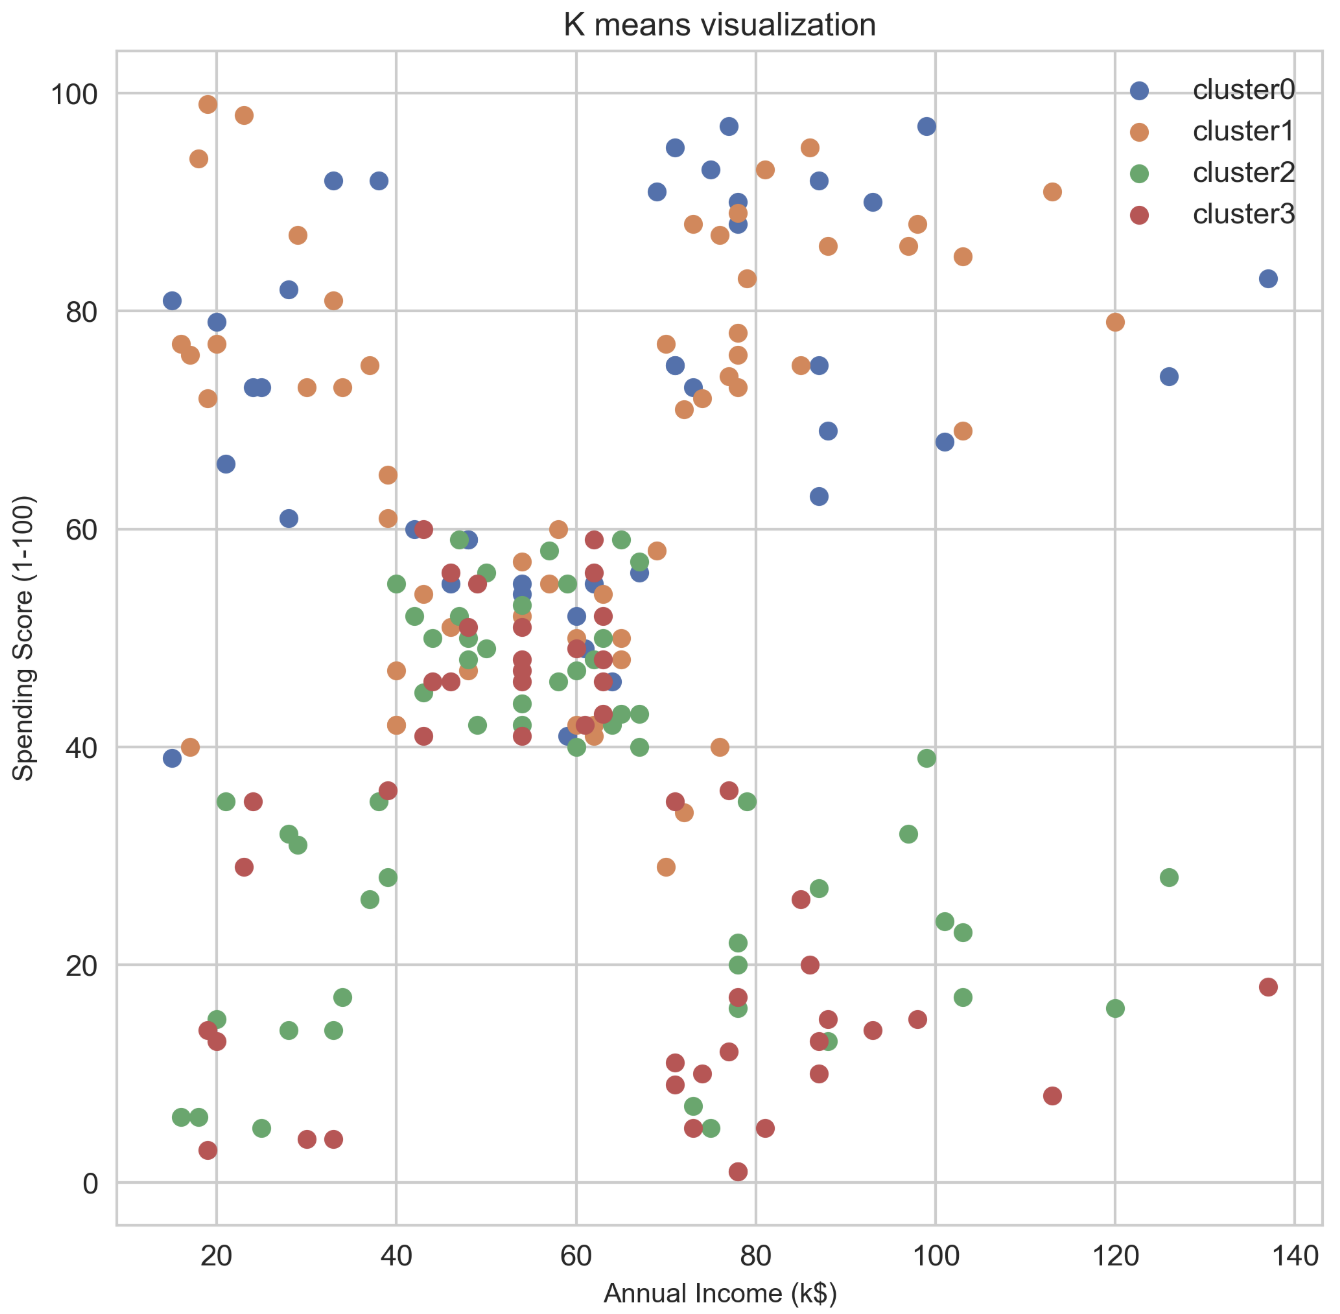

### 시각화의 의미

- 사용된 축:
    - **x축**: `Annual Income (k$)` → 소득 수준
    - **y축**: `Spending Score (1-100)` → 소비 성향
- 클러스터링 결과를 **소득–소비 특성** 기반으로 구분함
    
    → 예:
    
    - 고소득 + 고소비
    - 고소득 + 저소비
    - 저소득 + 고소비 등으로 군집 구분 가능

In [ ]:
# ✅ DBSCAN 클러스터링 알고리즘 이해를 위한 개념 정리

# ▶ 1. DBSCAN이란?
# DBSCAN은 밀도 기반의 비지도 학습 클러스터링 알고리즘임  
# 데이터가 밀집된 지역을 하나의 군집(cluster)으로 인식하고, 밀도가 희박한 포인트는 **이상치(noise)**로 간주함  
# KMeans처럼 군집 수를 미리 지정하지 않아도 됨

# ▶ 2. 작동 방식 요약
# DBSCAN은 각 데이터 포인트를 기준으로 주변 반경(ε, 엡실론) 내 이웃 수(min_samples)를 계산함  
# 이웃이 충분히 많으면 **핵심 포인트(core point)**로 간주함  
# 핵심 포인트로부터 인접한 점들을 연결하며 군집을 형성함  
# 이웃은 있지만 핵심은 아닌 포인트는 **경계 포인트(border point)**로 간주함  
# 핵심도 아니고 이웃도 적은 포인트는 **이상치(noise, -1)**로 라벨링함

# ▶ 3. 주요 하이퍼파라미터

# - eps (ε):  
#   → 한 점 주변을 탐색할 반경 거리  
#   → 작게 설정하면 군집이 잘게 쪼개지고, 크게 설정하면 군집 수가 줄어들 수 있음

# - min_samples:  
#   → 반경 내에 있어야 하는 **최소 이웃 수**  
#   → 이상치를 구분하는 기준으로 사용됨

# ▶ 4. 포인트 유형 정리

# - Core Point (핵심점):  
#   → 반경 내에 min_samples 이상 이웃이 있음 → 군집의 중심 역할

# - Border Point (경계점):  
#   → 반경 내 이웃 수는 부족하지만 **핵심점의 이웃**임

# - Noise Point (잡음점):  
#   → 어떠한 군집에도 속하지 못한 고립된 포인트 (결과 라벨: -1)

# ▶ 5. 장점

# ✅ 클러스터 수를 **사전 지정할 필요 없음**  
# ✅ **비선형, 불규칙한 모양의 군집**도 잘 탐지함  
# ✅ **이상치(outlier)** 탐지 가능

# ▶ 6. 단점

# ❌ eps, min_samples 설정이 어렵고 데이터에 따라 민감함  
# ❌ 밀도 차이가 큰 데이터에서는 군집이 제대로 분리되지 않을 수 있음  
# ❌ 고차원 데이터에서는 성능 저하 가능성 있음 (거리 기반 특성상)

# ▶ 7. 실전 적용 팁

# - eps 설정은 K-distance 그래프를 통해 시각적으로 찾는 것이 일반적임  
# - min_samples는 일반적으로 피처 수 이상으로 설정함 (예: 피처가 4개면 최소 4~5 이상 추천)  
# - 정규화 또는 표준화는 **필수 전처리**임 (거리 기반 알고리즘이므로 스케일에 민감함)

# -------------------------------------------------------------------------------------

# DBSCAN 모델 생성 및 시각화

# DBSCAN 모델 설정
DBSCAN_model = DBSCAN(eps=0.7, min_samples=5)
# DBSCAN(Density-Based Spatial Clustering of Applications with Noise) 클러스터링 모델 객체를 생성함
# eps=0.7은 점 간 거리를 기준으로 이웃으로 간주할 반경(ε, 엡실론) 값임
# min_samples=5는 한 점이 클러스터의 핵심점(core point)이 되기 위해 필요한 최소 이웃 수임
# 밀도 기반 군집화로, 밀도가 낮은 영역은 클러스터로 인식되지 않으며 이상치로 분류됨

# 군집화 모델 학습 및 클러스터 예측 결과 반환
DBSCAN_model.fit(df_minmax)
# 정규화된 데이터를 기준으로 DBSCAN 모델을 학습함
# 각 포인트의 밀도, 이웃 존재 여부에 따라 core point, border point, noise로 분류함

df2['cluster2'] = DBSCAN_model.fit_predict(df_minmax)
# DBSCAN의 예측 결과(클러스터 라벨)를 'cluster2'라는 새 열로 df2에 저장함
# noise로 간주된 포인트는 -1로 라벨링되며, 나머지는 0 이상의 정수형 클러스터 번호로 구분됨

# 시각화 설정
plt.figure(figsize = (8, 8))
# 시각화 영역의 전체 크기를 8×8인치로 설정함

for i in range(0, df2['cluster2'].max() + 1):
    # 클러스터 번호를 0부터 최대 클러스터 번호까지 반복함
    # noise(-1)는 제외되고 실제 클러스터만 시각화함

    plt.scatter(df2.loc[df2['cluster2'] == i, 
                        'Annual Income (k$)'], 
                df2.loc[df2['cluster2'] == i, 
                        'Spending Score (1-100)'], 
                label = 'cluster'+str(i))
    # cluster2 값이 i인 샘플만 선택하여 산점도 형태로 시각화함
    # x축은 연 소득, y축은 소비 점수 기준으로 각 클러스터 분포를 확인함
    # 클러스터마다 다른 색상으로 표현되며, 범례에 cluster0, cluster1 등의 이름으로 표시됨

plt.legend()
# 각 클러스터에 대한 범례를 추가하여 구분 가능하도록 함

plt.title('DBSCAN visualization', size = 12)
# 시각화의 제목을 설정함

plt.xlabel('Annual Income (k$)', size = 10)
# x축 라벨 설정

plt.ylabel('Spending Score (1-100)', size = 10)
# y축 라벨 설정

plt.show()
# 전체 시각화를 화면에 출력함
# DBSCAN 클러스터링이 데이터의 밀도 기반으로 어떻게 그룹을 형성했는지를 시각적으로 확인할 수 있음


### DBSCAN의 결과 해석

| 요소 | 의미 |
| --- | --- |
| `eps` | 반경 내 이웃을 판별하기 위한 거리 임계값 |
| `min_samples` | 해당 반경 내에 있어야 하는 최소 이웃 수 (core point 여부 판단 기준) |
| 클러스터 번호 | 일반적으로 `0, 1, 2, ...`로 표시되며, **-1은 이상치(noise)**를 의미함 |

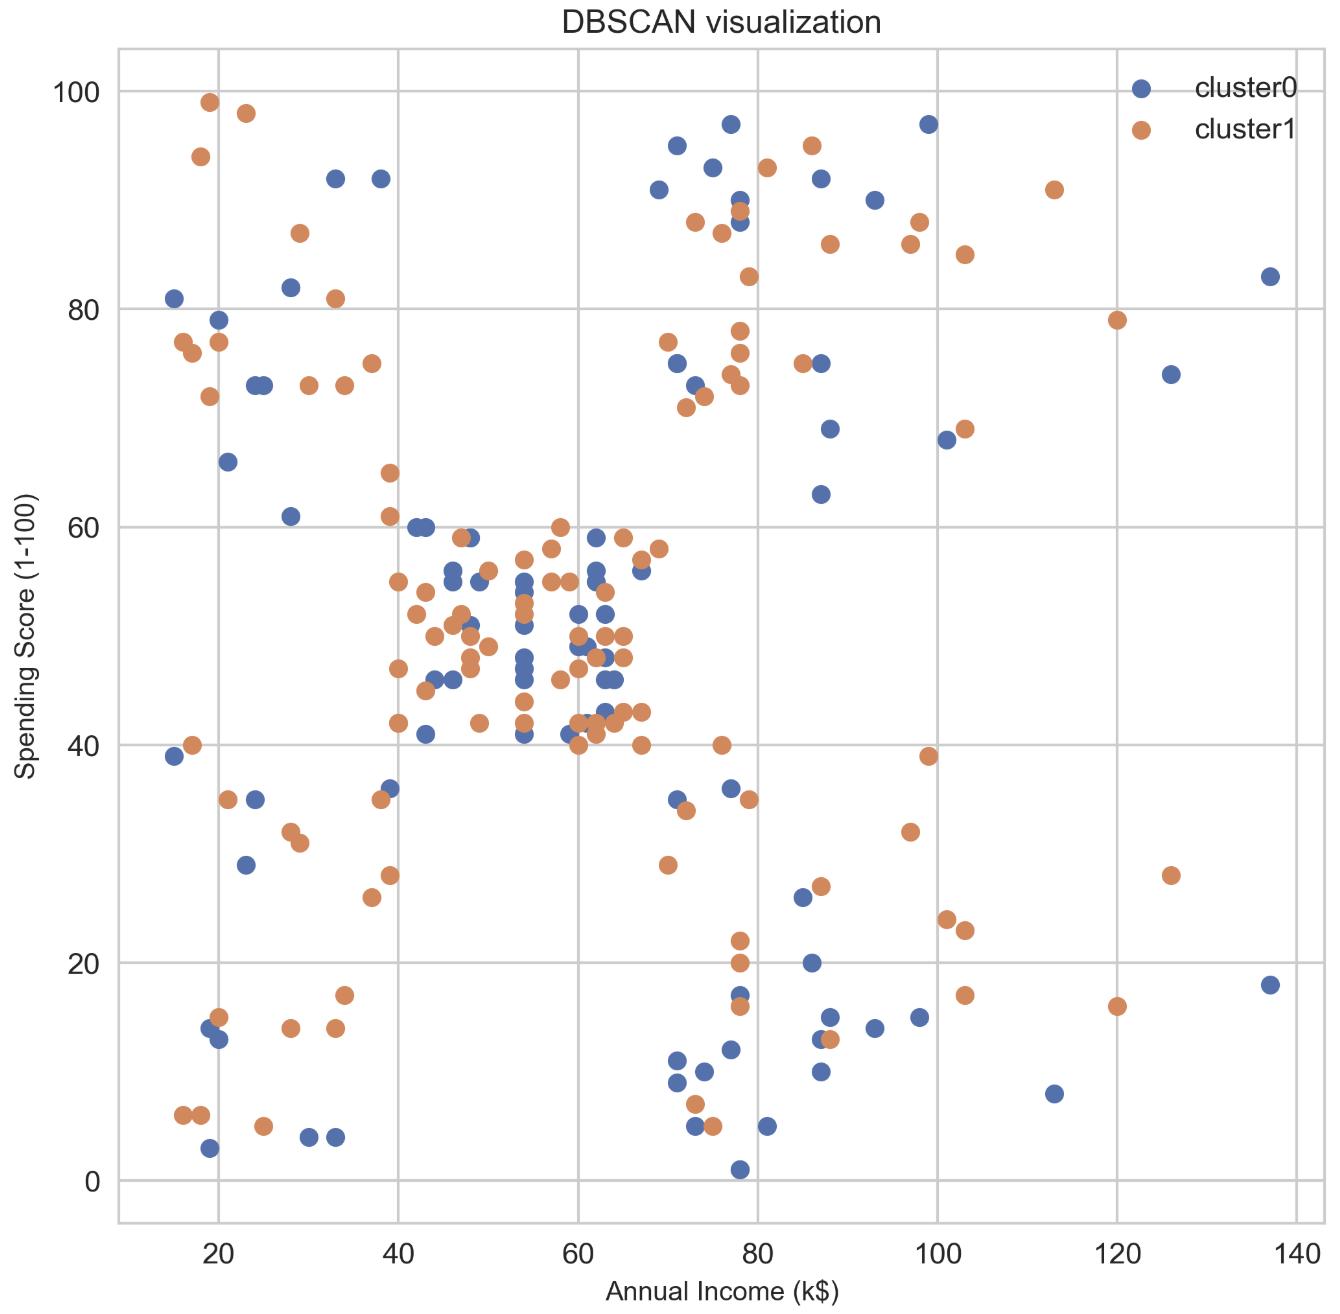

In [ ]:
# k-means 군집 별 특성 확인

df_kmeans = df2.groupby(['cluster1']).agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Gender_Male': 'mean'
}).reset_index()
# df2에서 cluster1(군집 번호) 기준으로 데이터를 그룹화함
# 각 군집에 대해 다음 변수들의 평균값을 계산함:
# - Age: 각 군집의 평균 연령
# - Annual Income: 평균 연 수입
# - Spending Score: 평균 소비 성향
# - Gender_Male: 남성 비율 (1 = 남성, 0 = 여성 → 평균은 남성 비율로 해석 가능)
# reset_index()는 그룹화 결과를 일반 DataFrame 형태로 변환하여 인덱스를 초기화함

df_kmeans['cnt'] = df2.groupby('cluster1')['Age'].count()
# 각 군집에 속한 샘플 수를 계산하여 'cnt' 열로 추가함
# 그룹화 후 count()는 결측값을 제외하고 해당 열의 개수를 셈
# 즉, 군집별 고객 수를 나타냄

df_kmeans.head()
# 군집별 평균 특성과 구성 인원 수를 요약한 테이블의 상위 5행을 출력함
# 군집의 대표 특성과 규모를 종합적으로 파악하는 데 유용한 요약 정보임


,cluster1,Age,Annual Income (k$),Spending Score (1-100),Gender_Male,cnt
0,0,28.250000,62.000000,71.675000,1.0,40
1,1,28.438596,59.666667,67.684211,0.0,57
2,2,48.109091,58.818182,34.781818,0.0,55
3,3,49.437500,62.416667,29.208333,1.0,48


In [ ]:
# DBSCAN 군집 별 특성 확인

df_DBSCAN = df2.groupby(['cluster2']).agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Gender_Male': 'mean'
}).reset_index()
# DBSCAN 결과로 생성된 cluster2 열을 기준으로 그룹화하여 군집별 특성을 요약함
# 각 군집에 대해 다음 항목의 평균을 계산함:
# - Age: 평균 나이
# - Annual Income: 평균 연간 수입
# - Spending Score: 평균 소비 점수
# - Gender_Male: 남성 비율 (1: 남성, 0: 여성 → 평균은 비율로 해석 가능)
# reset_index()는 그룹 인덱스를 일반 열로 전환하여 표 형태로 정리함

df_DBSCAN['cnt'] = df2.groupby('cluster2')['Age'].count()
# 각 cluster2(군집 번호)에 해당하는 고객 수(샘플 수)를 'cnt' 열로 추가함
# 군집별 구성 인원 수를 나타냄
# DBSCAN에서는 noise(-1) 클러스터도 포함되어 함께 계산됨

df_DBSCAN.head()
# 군집별 평균 특성과 군집 규모를 포함한 요약 테이블의 상위 5개 행을 출력함


,cluster2,Age,Annual Income (k$),Spending Score (1-100),Gender_Male,cnt
0,0,39.806818,62.227273,48.511364,1.0,88
1,1,38.098214,59.250000,51.526786,0.0,112
